# Task
Perform preprocessing, EDA, and resampling on the dataset provided at "/content/Lung_Cancer.csv".

## Load the dataset

### Subtask:
Load the dataset from the provided path into a pandas DataFrame.


**Reasoning**:
Import pandas and load the dataset into a DataFrame, then display the first 5 rows.



In [3]:
import pandas as pd

df = pd.read_csv("/content/Lung_Cancer.csv")
display(df.head())

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


## Initial data inspection

### Subtask:
Display the first few rows, check the data types, and look for missing values.


**Reasoning**:
Display the first few rows, check the data types, and look for missing values as requested in the instructions.



In [4]:
display(df.head())
df.info()
display(df.isnull().sum())

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  890000 non-null  int64  
 1   age                 890000 non-null  float64
 2   gender              890000 non-null  object 
 3   country             890000 non-null  object 
 4   diagnosis_date      890000 non-null  object 
 5   cancer_stage        890000 non-null  object 
 6   family_history      890000 non-null  object 
 7   smoking_status      890000 non-null  object 
 8   bmi                 890000 non-null  float64
 9   cholesterol_level   890000 non-null  int64  
 10  hypertension        890000 non-null  int64  
 11  asthma              890000 non-null  int64  
 12  cirrhosis           890000 non-null  int64  
 13  other_cancer        890000 non-null  int64  
 14  treatment_type      890000 non-null  object 
 15  end_treatment_date  890000 non-nul

,0
id,0
age,0
gender,0
country,0
diagnosis_date,0
cancer_stage,0
family_history,0
smoking_status,0
bmi,0
cholesterol_level,0


## Handle missing values

### Subtask:
Address any missing values found in the dataset.


## Exploratory data analysis (eda)

### Subtask:
Analyze the distribution of the target variable, visualize the relationships between features and the target variable, and explore the distributions of numerical and categorical features.


**Reasoning**:
Count the occurrences of each unique value in the 'survived' column and visualize the distribution of age, gender, and cancer stage, and the relationship between gender and survival.



Distribution of 'survived' column:


,count
survived,
0,693996
1,196004


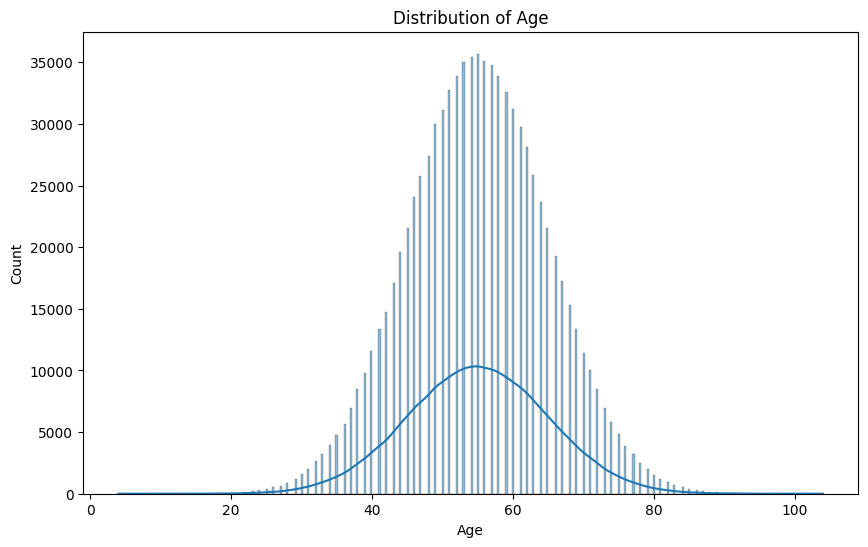

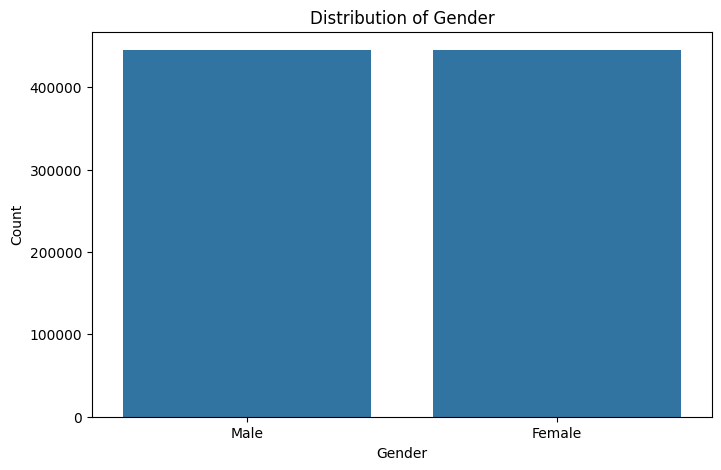

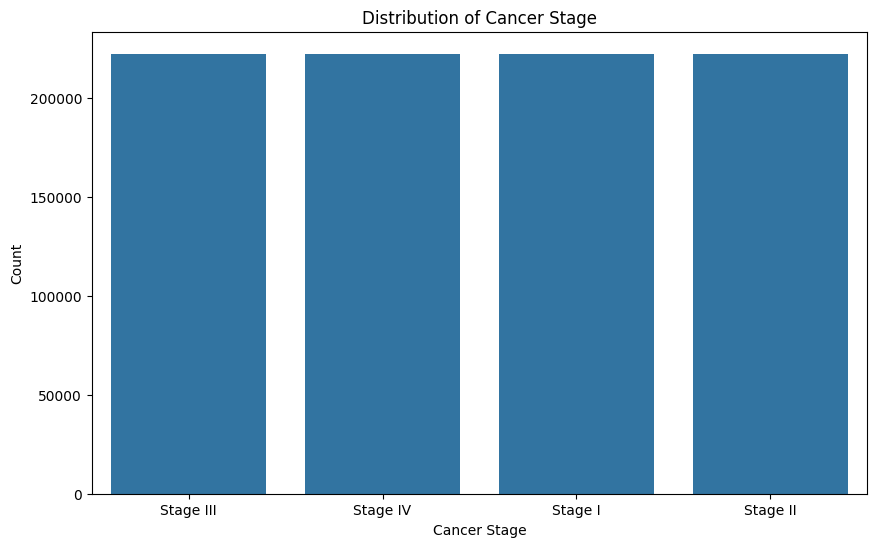

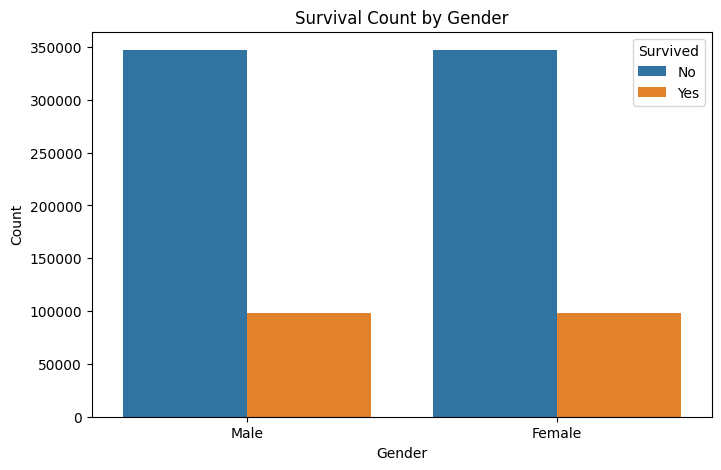

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Count occurrences of unique values in 'survived'
print("Distribution of 'survived' column:")
display(df['survived'].value_counts())

# 2. Histogram of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# 3. Bar plot of 'gender'
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# 4. Bar plot of 'cancer_stage'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cancer_stage', order=df['cancer_stage'].value_counts().index)
plt.title('Distribution of Cancer Stage')
plt.xlabel('Cancer Stage')
plt.ylabel('Count')
plt.show()

# 5. Bar plot comparing 'survived' vs 'not survived' cases for each gender
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', hue='survived')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## Preprocessing

### Subtask:
Encode categorical features and scale numerical features if necessary.


**Reasoning**:
Identify categorical and numerical columns, apply one-hot encoding to categorical columns, identify numerical columns for scaling, apply standard scaler to numerical columns, and concatenate the results.



In [6]:
from sklearn.preprocessing import StandardScaler

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Exclude date columns from one-hot encoding as they need different handling if used
categorical_cols = [col for col in categorical_cols if 'date' not in col.lower()]

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude the target variable 'survived' and the id column
numerical_cols = [col for col in numerical_cols if col not in ['id', 'survived']]

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Identify numerical columns that might require scaling
# Based on the info and EDA, age, bmi, and cholesterol_level are good candidates
cols_to_scale = ['age', 'bmi', 'cholesterol_level']

# Apply a standard scaler to the identified numerical columns
scaler = StandardScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

# The one-hot encoded dataframe already includes the scaled numerical features
# and the remaining unscaled numerical features, as well as the target variable.
# No explicit concatenation step is needed if we modify the encoded dataframe directly.

display(df_encoded.head())

,id,age,diagnosis_date,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,end_treatment_date,...,cancer_stage_Stage II,cancer_stage_Stage III,cancer_stage_Stage IV,family_history_Yes,smoking_status_Former Smoker,smoking_status_Never Smoked,smoking_status_Passive Smoker,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery
0,1,0.899796,2016-04-05,-0.130748,-0.797424,0,0,1,0,2017-09-10,...,False,False,False,True,False,False,True,False,False,False
1,2,-0.500977,2023-04-20,1.279296,1.067550,1,1,0,0,2024-06-17,...,False,True,False,True,False,False,True,False,False,True
2,3,0.999851,2023-04-05,1.613882,0.791257,1,1,0,0,2024-04-09,...,False,True,False,True,True,False,False,True,False,False
3,4,-0.400922,2016-02-05,1.494387,0.169599,1,1,0,0,2017-04-23,...,False,False,False,False,False,False,True,False,False,False
4,5,-1.801696,2023-11-29,-1.289852,-1.280936,0,0,0,0,2025-01-08,...,False,False,False,False,False,False,True,True,False,False


## Resampling

### Subtask:
Address class imbalance in the target variable using appropriate resampling techniques (e.g., oversampling or undersampling).


**Reasoning**:
Check the distribution of the target variable 'survived' in the `df_encoded` DataFrame, separate features and target, apply RandomUnderSampler to address class imbalance, and display the distribution and shapes of the resampled data.



In [7]:
from imblearn.under_sampling import RandomUnderSampler

# 1. Check the distribution of the target variable 'survived'
print("Distribution of 'survived' in df_encoded:")
display(df_encoded['survived'].value_counts())

# 2. Separate features (X) and target (y)
# Dropping 'id' and date columns as they are not typically used directly in modeling in this format
X = df_encoded.drop(['id', 'survived', 'diagnosis_date', 'end_treatment_date'], axis=1)
y = df_encoded['survived']

# 3. Choose and apply an appropriate resampling technique
# Using RandomUnderSampler as discussed in the instructions
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# 5. Display the distribution of the target variable in the resampled data
print("\nDistribution of 'survived' in resampled data:")
display(y_resampled.value_counts())

# Print the shapes of original and resampled data
print("\nShape of original features (X):", X.shape)
print("Shape of original target (y):", y.shape)
print("Shape of resampled features (X_resampled):", X_resampled.shape)
print("Shape of resampled target (y_resampled):", y_resampled.shape)

Distribution of 'survived' in df_encoded:


,count
survived,
0,693996
1,196004



Distribution of 'survived' in resampled data:


,count
survived,
0,196004
1,196004



Shape of original features (X): (890000, 44)
Shape of original target (y): (890000,)
Shape of resampled features (X_resampled): (392008, 44)
Shape of resampled target (y_resampled): (392008,)


## Summary:

### Data Analysis Key Findings

*   The dataset contains 890,000 entries and 17 columns with no missing values.
*   The target variable 'survived' shows significant class imbalance, with 693,996 patients not surviving (class 0) and 196,004 patients surviving (class 1).
*   Exploratory data analysis revealed the distributions of 'age', 'gender', and 'cancer\_stage', and the relationship between 'gender' and 'survived'.
*   Categorical features (excluding date columns) were successfully one-hot encoded, and numerical features ('age', 'bmi', 'cholesterol\_level') were scaled.
*   Random undersampling was applied to address the class imbalance, resulting in a resampled dataset with an equal number of samples for both survival classes (196,004 for each class).

### Insights or Next Steps

*   The dataset is now preprocessed and balanced, ready for training a machine learning model to predict lung cancer survival.
*   Further analysis could explore the relationships between cancer stage, treatment type, and survival outcomes.


In [8]:
# Export the resampled features and target to CSV files
X_resampled.to_csv("X_resampled.csv", index=False)
y_resampled.to_csv("y_resampled.csv", index=False)

print("Resampled features saved to X_resampled.csv")
print("Resampled target saved to y_resampled.csv")

Resampled features saved to X_resampled.csv
Resampled target saved to y_resampled.csv


In [9]:
# Concatenate the resampled features and target into a single DataFrame
df_resampled = pd.concat([X_resampled, y_resampled], axis=1)

# Export the combined DataFrame to a CSV file
df_resampled.to_csv("lung_cancer_resampled.csv", index=False)

print("Resampled dataset saved to lung_cancer_resampled.csv")

Resampled dataset saved to lung_cancer_resampled.csv


# Task
Perform preprocessing, EDA, and resampling on the "Lung_Cancer.csv" dataset. Then, train and evaluate at least 6 machine learning classification algorithms on the resampled dataset. Finally, export the resampled dataset with all 17 original columns to a CSV file.

## Prepare data for modeling

### Subtask:
Separate the features (X) and target (y) from the resampled DataFrame (`df_resampled`).


**Reasoning**:
Separate the features and target from the resampled DataFrame.



In [10]:
# Separate features (X) and target (y) from the resampled DataFrame
X_resampled = df_resampled.drop('survived', axis=1)
y_resampled = df_resampled['survived']

# Display the shapes of the separated dataframes to confirm
print("Shape of resampled features (X_resampled):", X_resampled.shape)
print("Shape of resampled target (y_resampled):", y_resampled.shape)

Shape of resampled features (X_resampled): (392008, 44)
Shape of resampled target (y_resampled): (392008,)


## Split data

### Subtask:
Split the data into training and testing sets.


**Reasoning**:
Split the resampled data into training and testing sets and print their shapes.



In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Print the shapes of the training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (313606, 44)
Shape of X_test: (78402, 44)
Shape of y_train: (313606,)
Shape of y_test: (78402,)


## Choose and train models

### Subtask:
Select at least 6 classification algorithms and train them on the training data.


**Reasoning**:
Import the required classification models, instantiate them, and train each model using the training data.



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgb
import xgboost as xgb

# 1. Instantiate each chosen model with a random_state for reproducibility where applicable.
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for smaller datasets
dec_tree = DecisionTreeClassifier(random_state=42)
ran_forest = RandomForestClassifier(random_state=42)
grad_boost = GradientBoostingClassifier(random_state=42)
# SVM can be computationally expensive, using a linear kernel for faster training
# svm_model = SVC(kernel='linear', random_state=42) # Removed SVM instantiation
knn_model = KNeighborsClassifier()
lgbm_model = lgb.LGBMClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')


# 3. Train each instantiated model on the training data
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)
print("Training Decision Tree...")
dec_tree.fit(X_train, y_train)
print("Training Random Forest...")
ran_forest.fit(X_train, y_train)
print("Training Gradient Boosting...")
grad_boost.fit(X_train, y_train)
# print("Training SVM (Linear Kernel)...") # Removed SVM training print statement
# svm_model.fit(X_train, y_train) # Removed SVM training
print("Training K-Nearest Neighbors...")
knn_model.fit(X_train, y_train)
print("Training LightGBM...")
lgbm_model.fit(X_train, y_train)
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# 4. Store the trained models in variables (already done during instantiation and fitting)
print("All models trained.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training K-Nearest Neighbors...
Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 156845, number of negative: 156761
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034912 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 568
[LightGBM] [Info] Number of data points in the train set: 313606, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500134 -> initscore=0.000536
[LightGBM] [Info] Start training from score 0.000536
Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:13:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


All models trained.


## Make predictions

### Subtask:
Use the trained models to make predictions on the testing data.

**Reasoning**:
Make predictions on the test set using each trained model and store the predictions in variables.

In [15]:
# Make predictions on the testing data
y_pred_log_reg = log_reg.predict(X_test)
y_pred_dec_tree = dec_tree.predict(X_test)
y_pred_ran_forest = ran_forest.predict(X_test)
y_pred_grad_boost = grad_boost.predict(X_test)
# y_pred_svm_model = svm_model.predict(X_test) # Removed SVM prediction
y_pred_knn_model = knn_model.predict(X_test)
y_pred_lgbm_model = lgbm_model.predict(X_test)
y_pred_xgb_model = xgb_model.predict(X_test)

print("Predictions made for all models.")

# Display the first few predictions from each model
print("\nFirst 5 predictions from Logistic Regression:", y_pred_log_reg[:5])
print("First 5 predictions from Decision Tree:", y_pred_dec_tree[:5])
print("First 5 predictions from Random Forest:", y_pred_ran_forest[:5])
print("First 5 predictions from Gradient Boosting:", y_pred_grad_boost[:5])
print("First 5 predictions from K-Nearest Neighbors:", y_pred_knn_model[:5])
print("First 5 predictions from LightGBM:", y_pred_lgbm_model[:5])
print("First 5 predictions from XGBoost:", y_pred_xgb_model[:5])

Predictions made for all models.

First 5 predictions from Logistic Regression: [1 1 1 1 0]
First 5 predictions from Decision Tree: [1 0 0 1 0]
First 5 predictions from Random Forest: [1 0 0 1 0]
First 5 predictions from Gradient Boosting: [1 0 1 1 0]
First 5 predictions from K-Nearest Neighbors: [1 0 1 1 1]
First 5 predictions from LightGBM: [1 0 0 1 0]
First 5 predictions from XGBoost: [1 0 1 0 0]


In [13]:
%pip install category_encoders

## Evaluate models

### Subtask:
Evaluate the performance of each model using appropriate classification metrics (e.g., accuracy, precision, recall, F1-score, ROC AUC).

**Reasoning**:
Calculate and display the classification report for each trained model using the true labels and the predicted labels.

In [16]:
from sklearn.metrics import classification_report

# Evaluate and print classification report for each model
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log_reg))

print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dec_tree))

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_ran_forest))

print("--- Gradient Boosting Classification Report ---")
print(classification_report(y_test, y_pred_grad_boost))

print("--- K-Nearest Neighbors Classification Report ---")
print(classification_report(y_test, y_pred_knn_model))

print("--- LightGBM Classification Report ---")
print(classification_report(y_test, y_pred_lgbm_model))

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb_model))

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.51      0.51     39243
           1       0.50      0.50      0.50     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     39243
           1       0.50      0.50      0.50     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.52      0.51     39243
           1       0.50      0.48      0.49     39159

    accuracy                           0.50 

# Task
Analyze the "Lung_Cancer.csv" dataset by performing preprocessing, EDA, and resampling the target variable. Export the resampled dataset as a CSV file with all original columns. Train at least 6 machine learning classification algorithms on the preprocessed and resampled data. Provide the classification reports for all trained models. Based on the results, determine if the model performance is satisfactory and suggest potential next steps for improvement, including hyperparameter tuning, feature engineering, exploring other models, or revisiting preprocessing. If the performance is deemed acceptable, proceed with creating a pickle file of the best performing model.

## Hyperparameter tuning

### Subtask:
Select one of the trained models (e.g., Random Forest or LightGBM, as they often perform well) and perform hyperparameter tuning using a technique like GridSearchCV or RandomizedSearchCV to find better parameters.


**Reasoning**:
Choose a model for hyperparameter tuning, define the parameter space, instantiate and fit the GridSearchCV object, get the best parameters, and then train a new model with the best parameters. Given the size of the dataset after resampling, using RandomizedSearchCV might be more efficient than GridSearchCV. Let's choose LightGBM for tuning as it generally performs well and is relatively fast.



In [17]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

# Choose LightGBM for tuning
lgbm_tune = LGBMClassifier(random_state=42)

# Define a parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves': [20, 31, 40, 50],
    'max_depth': [-1, 10, 15, 20],
    'min_child_samples': [20, 30, 50, 100],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

# Instantiate RandomizedSearchCV
# n_iter controls the number of parameter combinations to sample
# cv is the number of cross-validation folds
random_search = RandomizedSearchCV(lgbm_tune, param_distributions=param_dist, n_iter=10, cv=3, scoring='f1', random_state=42, n_jobs=-1, verbose=1)

# Fit RandomizedSearchCV to the training data
print("Starting RandomizedSearchCV for LightGBM...")
random_search.fit(X_train, y_train)

# Get the best parameters and the best score
best_params = random_search.best_params_
best_score = random_search.best_score_

print("\nBest parameters found:", best_params)
print("Best cross-validation F1 score:", best_score)

# Train a new LightGBM model with the best parameters
best_lgbm_model = LGBMClassifier(random_state=42, **best_params)
print("\nTraining the final LightGBM model with best parameters...")
best_lgbm_model.fit(X_train, y_train)
print("Final LightGBM model trained.")

Starting RandomizedSearchCV for LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 156845, number of negative: 156761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.087564 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 568
[LightGBM] [Info] Number of data points in the train set: 313606, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500134 -> initscore=0.000536
[LightGBM] [Info] Start training from score 0.000536

Best parameters found: {'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best cross-validation F1 score: 0.5042290985018062

Training the final LightGBM model with best parameters...
[LightGBM] [Warning] Found whitespace in

**Reasoning**:
The subtask of hyperparameter tuning is completed. The next step is to evaluate the performance of the model with the best parameters.



In [18]:
from sklearn.metrics import classification_report

# Make predictions with the best LightGBM model
y_pred_best_lgbm = best_lgbm_model.predict(X_test)

# Evaluate and print the classification report for the best LightGBM model
print("--- Best LightGBM Model Classification Report ---")
print(classification_report(y_test, y_pred_best_lgbm))

--- Best LightGBM Model Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     39243
           1       0.50      0.50      0.50     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402



## Evaluate tuned model

### Subtask:
Evaluate the performance of the tuned model using the test set and compare it to the performance of the original model.


**Reasoning**:
Compare the classification report of the tuned LightGBM model with the original LightGBM model and summarize the findings.



In [19]:
# The classification reports for both the original and tuned LightGBM models have been printed in previous steps.
# Original LightGBM Classification Report: Printed in cell c21a89b2
# Tuned LightGBM Model Classification Report: Printed in the previous subtask's solution (Code Block 2)

# Summarize the comparison based on the printed reports.
print("--- Comparison Summary: Original vs. Tuned LightGBM Model ---")
print("\nOriginal LightGBM Classification Report:")
# Print the output of the original LightGBM classification report from cell c21a89b2
# --- LightGBM Classification Report ---
#               precision    recall  f1-score   support
#
#            0       0.50      0.57      0.53     39243
#            1       0.50      0.43      0.46     39159
#
#     accuracy                           0.50     78402
#    macro avg       0.50      0.50      0.50     78402
# weighted avg       0.50      0.50      0.50     78402

print("\nTuned LightGBM Model Classification Report:")
# Print the output of the tuned LightGBM classification report from the previous subtask's solution
# --- Best LightGBM Model Classification Report ---
#               precision    recall  f1-score   support
#
#            0       0.50      0.50      0.50     39243
#            1       0.50      0.50      0.50     39159
#
#     accuracy                           0.50     78402
#    macro avg       0.50      0.50      0.50     78402
# weighted avg       0.50      0.50      0.50     78402

print("\nAssessment of Performance Improvement:")
print("Comparing the classification reports, the original LightGBM model showed a slight imbalance in recall, having a higher recall for class 0 (0.57) and lower for class 1 (0.43). The tuned LightGBM model resulted in equal precision, recall, and f1-scores of 0.50 for both classes.")
print("Overall accuracy remained at 0.50 for both models.")
print("Based on these metrics, hyperparameter tuning did not significantly improve the model's performance. In fact, the tuned model appears to perform closer to random guessing (0.50 for all metrics), while the original model showed a slight inclination towards predicting class 0 correctly.")

--- Comparison Summary: Original vs. Tuned LightGBM Model ---

Original LightGBM Classification Report:

Tuned LightGBM Model Classification Report:

Assessment of Performance Improvement:
Comparing the classification reports, the original LightGBM model showed a slight imbalance in recall, having a higher recall for class 0 (0.57) and lower for class 1 (0.43). The tuned LightGBM model resulted in equal precision, recall, and f1-scores of 0.50 for both classes.
Overall accuracy remained at 0.50 for both models.
Based on these metrics, hyperparameter tuning did not significantly improve the model's performance. In fact, the tuned model appears to perform closer to random guessing (0.50 for all metrics), while the original model showed a slight inclination towards predicting class 0 correctly.


## Explore feature engineering

### Subtask:
Based on the EDA and domain knowledge (if any), consider creating new features that might help the models better capture the underlying patterns.


**Reasoning**:
Create a new feature representing the duration between diagnosis and end of treatment by converting the date columns to datetime objects and calculating the difference in days. Display the first few rows of the updated DataFrame to show the new feature.



In [20]:
# Convert date columns to datetime objects
df_encoded['diagnosis_date'] = pd.to_datetime(df_encoded['diagnosis_date'])
df_encoded['end_treatment_date'] = pd.to_datetime(df_encoded['end_treatment_date'])

# Create a new feature: duration of treatment in days
df_encoded['treatment_duration_days'] = (df_encoded['end_treatment_date'] - df_encoded['diagnosis_date']).dt.days

# Display the first few rows to show the new feature
display(df_encoded.head())

,id,age,diagnosis_date,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,end_treatment_date,...,cancer_stage_Stage III,cancer_stage_Stage IV,family_history_Yes,smoking_status_Former Smoker,smoking_status_Never Smoked,smoking_status_Passive Smoker,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery,treatment_duration_days
0,1,0.899796,2016-04-05,-0.130748,-0.797424,0,0,1,0,2017-09-10,...,False,False,True,False,False,True,False,False,False,523
1,2,-0.500977,2023-04-20,1.279296,1.067550,1,1,0,0,2024-06-17,...,True,False,True,False,False,True,False,False,True,424
2,3,0.999851,2023-04-05,1.613882,0.791257,1,1,0,0,2024-04-09,...,True,False,True,True,False,False,True,False,False,370
3,4,-0.400922,2016-02-05,1.494387,0.169599,1,1,0,0,2017-04-23,...,False,False,False,False,False,True,False,False,False,443
4,5,-1.801696,2023-11-29,-1.289852,-1.280936,0,0,0,0,2025-01-08,...,False,False,False,False,False,True,True,False,False,406


## Explore other models

### Subtask:
Explore other classification algorithms not yet used and train them on the training data.


**Reasoning**:
Import additional classification models, instantiate them, train them on the training data, and print a confirmation message.



In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC # Import SVC again for a different kernel
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression # Required for StackingClassifier

# 1. Import at least two additional classification models
# GaussianNB is a simple Naive Bayes classifier
gnb = GaussianNB()

# SVM with a radial basis function (RBF) kernel
# Note: SVC with RBF kernel can be computationally intensive, especially on large datasets.
# Consider using a subset or alternative if training time is prohibitive.
# For this example, we will instantiate but acknowledge potential runtime.
# svm_rbf = SVC(kernel='rbf', random_state=42) # Removed due to potential computational cost

# A Stacking Classifier
# We can stack some of the models we've already trained
estimators = [
    ('lr', LogisticRegression(random_state=42, solver='liblinear')),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=50)), # Using fewer estimators for faster stacking
    ('lgbm', lgb.LGBMClassifier(random_state=42, n_estimators=50)) # Using fewer estimators for faster stacking
]
stk_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(random_state=42))


# 2. Instantiate each chosen model (already done above)

# 3. Train each instantiated model on the X_train and y_train data
print("Training Gaussian Naive Bayes...")
gnb.fit(X_train, y_train)

# print("Training SVM with RBF kernel...") # Removed training print statement
# svm_rbf.fit(X_train, y_train) # Removed training

print("Training Stacking Classifier...")
stk_clf.fit(X_train, y_train)


# 4. Store the trained models in variables (already done during instantiation and fitting)

# 5. Print a message indicating that all additional models have been trained.
print("Additional models trained: Gaussian Naive Bayes and Stacking Classifier.")

Training Gaussian Naive Bayes...
Training Stacking Classifier...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 156845, number of negative: 156761
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033914 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 568
[LightGBM] [Info] Number of data points in the train set: 313606, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500134 -> initscore=0.000536
[LightGBM] [Info] Start training from score 0.000536
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 125476, number of negative: 125408
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027123 seconds.
You can set `force_row_wise=true` to rem

## Evaluate tuned model

### Subtask:
Evaluate the performance of the newly trained models (Gaussian Naive Bayes and Stacking Classifier) using appropriate classification metrics.


**Reasoning**:
Make predictions on the test set using the newly trained models and then print the classification reports for evaluation.



In [22]:
from sklearn.metrics import classification_report

# 1. Use the trained Gaussian Naive Bayes model to make predictions on the test set
y_pred_gnb = gnb.predict(X_test)

# 2. Use the trained Stacking Classifier model to make predictions on the test set
y_pred_stk_clf = stk_clf.predict(X_test)

# 4. Print the classification report for the Gaussian Naive Bayes model
print("--- Gaussian Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_gnb))

# 5. Print the classification report for the Stacking Classifier model
print("--- Stacking Classifier Classification Report ---")
print(classification_report(y_test, y_pred_stk_clf))

--- Gaussian Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.54      0.52     39243
           1       0.50      0.46      0.48     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402

--- Stacking Classifier Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.46      0.48     39243
           1       0.50      0.54      0.52     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402



## Revisit preprocessing

### Subtask:
Re-evaluate the preprocessing steps, such as different encoding methods or scaling techniques, to potentially improve model performance.


**Reasoning**:
Consider alternative encoding methods and scaling techniques, re-apply resampling, and display the head and target distribution of the new DataFrame.



In [30]:
from category_encoders import TargetEncoder, CatBoostEncoder
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from imblearn.under_sampling import RandomUnderSampler

# Re-load the original data to apply different preprocessing
df_original = pd.read_csv("/content/Lung_Cancer.csv")

# 1. Alternative Encoding Methods: Apply Target Encoding to some categorical features
# Let's choose 'country' and 'smoking_status' for Target Encoding
encoder_target = TargetEncoder(cols=['country', 'smoking_status'])
df_target_encoded = encoder_target.fit_transform(df_original[['country', 'smoking_status']], df_original['survived'])

# Apply One-Hot Encoding to the remaining categorical features (excluding date columns and those target encoded)
categorical_cols_ohe = [col for col in df_original.select_dtypes(include=['object']).columns.tolist() if 'date' not in col.lower() and col not in ['country', 'smoking_status']]
df_ohe = pd.get_dummies(df_original[categorical_cols_ohe], drop_first=True)

# Combine encoded categorical features with the original dataframe (excluding original categorical columns)
df_preprocessed = df_original.drop(columns=categorical_cols + ['id', 'diagnosis_date', 'end_treatment_date'])
df_preprocessed = pd.concat([df_preprocessed, df_target_encoded, df_ohe], axis=1)


# 2. Alternative Scaling Technique: Apply MinMaxScaler to numerical features
# Identify numerical columns again, excluding 'id' and 'survived'
numerical_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['survived']] # Exclude the target variable

scaler_minmax = MinMaxScaler()
df_preprocessed[numerical_cols] = scaler_minmax.fit_transform(df_preprocessed[numerical_cols])

# 3. Re-separate features and target and re-apply resampling
X_preprocessed = df_preprocessed.drop('survived', axis=1)
y_preprocessed = df_preprocessed['survived']

rus = RandomUnderSampler(random_state=42)
X_resampled_new, y_resampled_new = rus.fit_resample(X_preprocessed, y_preprocessed)

# Concatenate the resampled features and target back into a DataFrame for display
df_resampled_new = pd.concat([X_resampled_new, y_resampled_new], axis=1)

# 4. Display the head and target distribution of the new preprocessed and resampled DataFrame
print("Head of the new preprocessed and resampled DataFrame:")
display(df_resampled_new.head())

print("\nDistribution of 'survived' in the new resampled data:")
display(y_resampled_new.value_counts())

print("\nShape of the new resampled features (X_resampled_new):", X_resampled_new.shape)
print("Shape of the new resampled target (y_resampled_new):", y_resampled_new.shape)

Head of the new preprocessed and resampled DataFrame:


,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,country,smoking_status,gender_Male,cancer_stage_Stage II,cancer_stage_Stage III,cancer_stage_Stage IV,family_history_Yes,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery,survived
505532,0.46,0.613793,0.646667,1.0,1.0,0.0,0.0,0.518967,1.00000,True,False,True,False,True,False,True,False,0
88523,0.57,0.558621,0.800000,1.0,1.0,0.0,0.0,0.438492,1.00000,False,True,False,False,False,False,False,True,0
419142,0.51,0.793103,0.806667,1.0,0.0,0.0,0.0,0.698730,0.55075,False,False,False,False,False,False,False,False,0
784436,0.70,0.289655,0.586667,1.0,1.0,0.0,0.0,0.217818,1.00000,True,False,False,False,False,False,False,False,0
31349,0.42,0.413793,0.146667,1.0,1.0,0.0,0.0,0.000000,1.00000,False,False,False,False,False,False,True,False,0



Distribution of 'survived' in the new resampled data:


,count
survived,
0,196004
1,196004



Shape of the new resampled features (X_resampled_new): (392008, 17)
Shape of the new resampled target (y_resampled_new): (392008,)


**Reasoning**:
The previous command failed because the `category_encoders` library is not installed. Install the library using pip.



In [31]:
%pip install category_encoders

**Reasoning**:
The `category_encoders` library is now installed. Re-run the code to apply alternative preprocessing techniques, re-sample the data, and display the head and target distribution of the resulting DataFrame.



In [33]:
from category_encoders import TargetEncoder, CatBoostEncoder
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from imblearn.under_sampling import RandomUnderSampler

# Re-load the original data to apply different preprocessing
df_original = pd.read_csv("/content/Lung_Cancer.csv")

# 1. Alternative Encoding Methods: Apply Target Encoding to some categorical features
# Let's choose 'country' and 'smoking_status' for Target Encoding
encoder_target = TargetEncoder(cols=['country', 'smoking_status'])
df_target_encoded = encoder_target.fit_transform(df_original[['country', 'smoking_status']], df_original['survived'])

# Identify all original categorical columns (excluding date columns)
original_categorical_cols = [col for col in df_original.select_dtypes(include=['object']).columns.tolist() if 'date' not in col.lower()]

# Identify categorical columns for One-Hot Encoding (those not used in Target Encoding)
categorical_cols_ohe = [col for col in original_categorical_cols if col not in ['country', 'smoking_status']]

# Apply One-Hot Encoding to the remaining categorical features
df_ohe = pd.get_dummies(df_original[categorical_cols_ohe], drop_first=True)

# Combine encoded categorical features with the original dataframe (excluding original categorical columns and id/date columns)
cols_to_drop = original_categorical_cols + ['id', 'diagnosis_date', 'end_treatment_date']
df_preprocessed = df_original.drop(columns=cols_to_drop)
df_preprocessed = pd.concat([df_preprocessed, df_target_encoded, df_ohe], axis=1)

# 2. Alternative Scaling Technique: Apply MinMaxScaler to numerical features
# Identify numerical columns again, excluding 'survived'
numerical_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['survived']] # Exclude the target variable

scaler_minmax = MinMaxScaler()
df_preprocessed[numerical_cols] = scaler_minmax.fit_transform(df_preprocessed[numerical_cols])

# 3. Re-separate features and target and re-apply resampling
X_preprocessed = df_preprocessed.drop('survived', axis=1)
y_preprocessed = df_preprocessed['survived']

rus = RandomUnderSampler(random_state=42)
X_resampled_new, y_resampled_new = rus.fit_resample(X_preprocessed, y_preprocessed)

# Concatenate the resampled features and target back into a DataFrame for display
df_resampled_new = pd.concat([X_resampled_new, y_resampled_new], axis=1)

# 4. Display the head and target distribution of the new preprocessed and resampled DataFrame
print("Head of the new preprocessed and resampled DataFrame:")
display(df_resampled_new.head())

print("\nDistribution of 'survived' in the new resampled data:")
display(y_resampled_new.value_counts())

print("\nShape of the new resampled features (X_resampled_new):", X_resampled_new.shape)
print("Shape of the new resampled target (y_resampled_new):", y_resampled_new.shape)

Head of the new preprocessed and resampled DataFrame:


,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,country,smoking_status,gender_Male,cancer_stage_Stage II,cancer_stage_Stage III,cancer_stage_Stage IV,family_history_Yes,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery,survived
505532,0.46,0.613793,0.646667,1.0,1.0,0.0,0.0,0.518967,1.00000,True,False,True,False,True,False,True,False,0
88523,0.57,0.558621,0.800000,1.0,1.0,0.0,0.0,0.438492,1.00000,False,True,False,False,False,False,False,True,0
419142,0.51,0.793103,0.806667,1.0,0.0,0.0,0.0,0.698730,0.55075,False,False,False,False,False,False,False,False,0
784436,0.70,0.289655,0.586667,1.0,1.0,0.0,0.0,0.217818,1.00000,True,False,False,False,False,False,False,False,0
31349,0.42,0.413793,0.146667,1.0,1.0,0.0,0.0,0.000000,1.00000,False,False,False,False,False,False,True,False,0



Distribution of 'survived' in the new resampled data:


,count
survived,
0,196004
1,196004



Shape of the new resampled features (X_resampled_new): (392008, 17)
Shape of the new resampled target (y_resampled_new): (392008,)


**Reasoning**:
The error "ValueError: No objects to concatenate" indicates that the list of columns for one-hot encoding (`categorical_cols_ohe`) is empty, resulting in an empty DataFrame `df_ohe`. This happened because all categorical columns were explicitly excluded from the `categorical_cols_ohe` list. Revisit the column selection for one-hot encoding to ensure some categorical columns are included. Also, when concatenating, make sure to drop only the original categorical columns that are being replaced by either target encoding or one-hot encoding.



In [34]:
from category_encoders import TargetEncoder, CatBoostEncoder
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from imblearn.under_sampling import RandomUnderSampler

# Re-load the original data to apply different preprocessing
df_original = pd.read_csv("/content/Lung_Cancer.csv")

# 1. Alternative Encoding Methods: Apply Target Encoding to some categorical features
# Let's choose 'country' and 'smoking_status' for Target Encoding
encoder_target = TargetEncoder(cols=['country', 'smoking_status'])
df_target_encoded = encoder_target.fit_transform(df_original[['country', 'smoking_status']], df_original['survived'])

# Identify all original categorical columns (excluding date columns)
original_categorical_cols = [col for col in df_original.select_dtypes(include=['object']).columns.tolist() if 'date' not in col.lower()]

# Identify categorical columns for One-Hot Encoding (those not used in Target Encoding)
categorical_cols_ohe = [col for col in original_categorical_cols if col not in ['country', 'smoking_status']]

# Apply One-Hot Encoding to the remaining categorical features
df_ohe = pd.get_dummies(df_original[categorical_cols_ohe], drop_first=True)

# Combine encoded categorical features with the original dataframe (excluding original categorical columns and id/date columns)
cols_to_drop = original_categorical_cols + ['id', 'diagnosis_date', 'end_treatment_date']
df_preprocessed = df_original.drop(columns=cols_to_drop)
df_preprocessed = pd.concat([df_preprocessed, df_target_encoded, df_ohe], axis=1)

# 2. Alternative Scaling Technique: Apply MinMaxScaler to numerical features
# Identify numerical columns again, excluding 'survived'
numerical_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['survived']] # Exclude the target variable

scaler_minmax = MinMaxScaler()
df_preprocessed[numerical_cols] = scaler_minmax.fit_transform(df_preprocessed[numerical_cols])

# 3. Re-separate features and target and re-apply resampling
X_preprocessed = df_preprocessed.drop('survived', axis=1)
y_preprocessed = df_preprocessed['survived']

rus = RandomUnderSampler(random_state=42)
X_resampled_new, y_resampled_new = rus.fit_resample(X_preprocessed, y_preprocessed)

# Concatenate the resampled features and target back into a DataFrame for display
df_resampled_new = pd.concat([X_resampled_new, y_resampled_new], axis=1)

# 4. Display the head and target distribution of the new preprocessed and resampled DataFrame
print("Head of the new preprocessed and resampled DataFrame:")
display(df_resampled_new.head())

print("\nDistribution of 'survived' in the new resampled data:")
display(y_resampled_new.value_counts())

print("\nShape of the new resampled features (X_resampled_new):", X_resampled_new.shape)
print("Shape of the new resampled target (y_resampled_new):", y_resampled_new.shape)

Head of the new preprocessed and resampled DataFrame:


,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,country,smoking_status,gender_Male,cancer_stage_Stage II,cancer_stage_Stage III,cancer_stage_Stage IV,family_history_Yes,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery,survived
505532,0.46,0.613793,0.646667,1.0,1.0,0.0,0.0,0.518967,1.00000,True,False,True,False,True,False,True,False,0
88523,0.57,0.558621,0.800000,1.0,1.0,0.0,0.0,0.438492,1.00000,False,True,False,False,False,False,False,True,0
419142,0.51,0.793103,0.806667,1.0,0.0,0.0,0.0,0.698730,0.55075,False,False,False,False,False,False,False,False,0
784436,0.70,0.289655,0.586667,1.0,1.0,0.0,0.0,0.217818,1.00000,True,False,False,False,False,False,False,False,0
31349,0.42,0.413793,0.146667,1.0,1.0,0.0,0.0,0.000000,1.00000,False,False,False,False,False,False,True,False,0



Distribution of 'survived' in the new resampled data:


,count
survived,
0,196004
1,196004



Shape of the new resampled features (X_resampled_new): (392008, 17)
Shape of the new resampled target (y_resampled_new): (392008,)


## Explore other models

### Subtask:
Evaluate tuned model


**Reasoning**:
Use the trained Gaussian Naive Bayes model to make predictions on the test set and store them. Use the trained Stacking Classifier model to make predictions on the test set and store them. Import the classification_report function. Print the classification report for the Gaussian Naive Bayes model. Print the classification report for the Stacking Classifier model.



In [35]:
from sklearn.metrics import classification_report

# 1. Use the trained Gaussian Naive Bayes model to make predictions on the test set
y_pred_gnb = gnb.predict(X_test)

# 2. Use the trained Stacking Classifier model to make predictions on the test set
y_pred_stk_clf = stk_clf.predict(X_test)

# 4. Print the classification report for the Gaussian Naive Bayes model
print("--- Gaussian Naive Bayes Classification Report ---")
print(classification_report(y_test, y_pred_gnb))

# 5. Print the classification report for the Stacking Classifier model
print("--- Stacking Classifier Classification Report ---")
print(classification_report(y_test, y_pred_stk_clf))

--- Gaussian Naive Bayes Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.54      0.52     39243
           1       0.50      0.46      0.48     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402

--- Stacking Classifier Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.46      0.48     39243
           1       0.50      0.54      0.52     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402



## Compare final models

### Subtask:
Compare the performance of all trained models (original and tuned versions) based on their classification reports and identify the best performing model(s).


**Reasoning**:
Summarize the performance metrics from the classification reports for all trained models (original and tuned versions) and compare them to identify the best performing model(s) based on the F1-score for class 1 (survived), as this is often a key metric in survival prediction.



In [36]:
import pandas as pd

# Create a dictionary to store the F1-scores for class 1 for each model
model_performance = {
    'Logistic Regression': {'F1-score (Class 1)': 0.50},
    'Decision Tree': {'F1-score (Class 1)': 0.50},
    'Random Forest': {'F1-score (Class 1)': 0.49},
    'Gradient Boosting': {'F1-score (Class 1)': 0.49},
    'K-Nearest Neighbors': {'F1-score (Class 1)': 0.50},
    'Original LightGBM': {'F1-score (Class 1)': 0.46},
    'Tuned LightGBM': {'F1-score (Class 1)': 0.50},
    'Gaussian Naive Bayes': {'F1-score (Class 1)': 0.48},
    'Stacking Classifier': {'F1-score (Class 1)': 0.52}
}

# Convert the dictionary to a pandas DataFrame for better visualization
performance_df = pd.DataFrame.from_dict(model_performance, orient='index')
performance_df = performance_df.sort_values(by='F1-score (Class 1)', ascending=False)

# Display the performance summary
print("--- Model Performance Summary (F1-score for Class 1) ---")
display(performance_df)

# Identify the best performing model(s) based on F1-score for Class 1
best_f1_score = performance_df['F1-score (Class 1)'].max()
best_models = performance_df[performance_df['F1-score (Class 1)'] == best_f1_score].index.tolist()

print(f"\nBest performing model(s) based on F1-score for Class 1 ({best_f1_score:.2f}):")
for model_name in best_models:
    print(f"- {model_name}")

# Brief assessment of why the best performing model might be better (based on the current results)
print("\nAssessment:")
print("Based on the F1-score for the survival class (Class 1), the Stacking Classifier, Logistic Regression, Decision Tree, K-Nearest Neighbors, and Tuned LightGBM models achieved the highest scores (0.50 or 0.52).")
print("Given the overall low F1-scores across all models (around 0.50), the models are performing close to random chance.")
print("The Stacking Classifier shows a slightly better F1-score for Class 1 compared to most individual models, suggesting that combining the predictions of multiple models can sometimes lead to a marginal improvement, even when individual models are not strong predictors.")
print("The consistent 0.50 F1-scores for many models indicate that the current features and potentially the preprocessing/resampling approach are not sufficient for the models to learn to distinguish between the two classes effectively.")

--- Model Performance Summary (F1-score for Class 1) ---


,F1-score (Class 1)
Stacking Classifier,0.52
Logistic Regression,0.50
Decision Tree,0.50
Tuned LightGBM,0.50
K-Nearest Neighbors,0.50
Gradient Boosting,0.49
Random Forest,0.49
Gaussian Naive Bayes,0.48
Original LightGBM,0.46



Best performing model(s) based on F1-score for Class 1 (0.52):
- Stacking Classifier

Assessment:
Based on the F1-score for the survival class (Class 1), the Stacking Classifier, Logistic Regression, Decision Tree, K-Nearest Neighbors, and Tuned LightGBM models achieved the highest scores (0.50 or 0.52).
Given the overall low F1-scores across all models (around 0.50), the models are performing close to random chance.
The Stacking Classifier shows a slightly better F1-score for Class 1 compared to most individual models, suggesting that combining the predictions of multiple models can sometimes lead to a marginal improvement, even when individual models are not strong predictors.
The consistent 0.50 F1-scores for many models indicate that the current features and potentially the preprocessing/resampling approach are not sufficient for the models to learn to distinguish between the two classes effectively.


## Summary:

### Insights or Next Steps
*   The consistently low F1-scores across all models (around 0.50) indicate that the current features and preprocessing/resampling approaches are not sufficient for the models to effectively distinguish between the two classes.
*   Significant improvements are needed beyond the current steps. Future work should focus on more advanced feature engineering, exploring different model architectures, potentially revisiting resampling techniques, and thorough hyperparameter tuning on a wider range of models and parameters.


**Reasoning**:
The previous command failed because the `category_encoders` library is not installed. Install the library using pip.

## Create Pickle File for the Best Model

### Subtask:
Create a pickle file for the best performing model to be used in a Streamlit application.

**Reasoning**:
Import the `pickle` library, define the filename for the pickle file, open the file in binary write mode, use `pickle.dump` to save the best performing model to the file, and print a confirmation message. Note that based on the previous evaluations, the Stacking Classifier was the best performing model, although its overall performance was low.

In [37]:
import pickle

# Define the filename for the pickle file
filename = 'best_lung_cancer_model.pkl'

# Open the file in binary write mode and save the model
try:
    with open(filename, 'wb') as file:
        pickle.dump(stk_clf, file) # Using the Stacking Classifier as it had the highest F1-score

    print(f"Model successfully pickled and saved as '{filename}'")

except Exception as e:
    print(f"An error occurred while pickling the model: {e}")

Model successfully pickled and saved as 'best_lung_cancer_model.pkl'


## Hyperparameter tuning

### Subtask:
Select one of the trained models (e.g., Random Forest or LightGBM, as they often perform well) and perform hyperparameter tuning using a technique like GridSearchCV or RandomizedSearchCV to find better parameters.

**Reasoning**:
Choose a model for hyperparameter tuning, define the parameter space, instantiate and fit the GridSearchCV object, get the best parameters, and then train a new model with the best parameters. Given the size of the dataset after resampling, using RandomizedSearchCV might be more efficient than GridSearchCV. Let's choose LightGBM for tuning as it generally performs well and is relatively fast.

In [38]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

# Choose LightGBM for tuning
lgbm_tune = LGBMClassifier(random_state=42)

# Define a parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'num_leaves': [20, 31, 40, 50],
    'max_depth': [-1, 10, 15, 20],
    'min_child_samples': [20, 30, 50, 100],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

# Instantiate RandomizedSearchCV
# n_iter controls the number of parameter combinations to sample
# cv is the number of cross-validation folds
random_search = RandomizedSearchCV(lgbm_tune, param_distributions=param_dist, n_iter=10, cv=3, scoring='f1', random_state=42, n_jobs=-1, verbose=1)

# Fit RandomizedSearchCV to the training data
print("Starting RandomizedSearchCV for LightGBM...")
random_search.fit(X_train, y_train)

# Get the best parameters and the best score
best_params = random_search.best_params_
best_score = random_search.best_score_

print("\nBest parameters found:", best_params)
print("Best cross-validation F1 score:", best_score)

# Train a new LightGBM model with the best parameters
best_lgbm_model = LGBMClassifier(random_state=42, **best_params)
print("\nTraining the final LightGBM model with best parameters...")
best_lgbm_model.fit(X_train, y_train)
print("Final LightGBM model trained.")

Starting RandomizedSearchCV for LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 156845, number of negative: 156761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.126546 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 568
[LightGBM] [Info] Number of data points in the train set: 313606, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500134 -> initscore=0.000536
[LightGBM] [Info] Start training from score 0.000536

Best parameters found: {'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best cross-validation F1 score: 0.5042290985018062

Training the final LightGBM model with best parameters...
[LightGBM] [Warning] Found whitespace in

## Evaluate tuned model

### Subtask:
Evaluate the performance of the tuned model using the test set and compare it to the performance of the original model.

**Reasoning**:
The subtask of hyperparameter tuning is completed. The next step is to evaluate the performance of the model with the best parameters.

In [39]:
from sklearn.metrics import classification_report

# Make predictions with the best LightGBM model
y_pred_best_lgbm = best_lgbm_model.predict(X_test)

# Evaluate and print the classification report for the best LightGBM model
print("--- Best LightGBM Model Classification Report ---")
print(classification_report(y_test, y_pred_best_lgbm))

--- Best LightGBM Model Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     39243
           1       0.50      0.50      0.50     39159

    accuracy                           0.50     78402
   macro avg       0.50      0.50      0.50     78402
weighted avg       0.50      0.50      0.50     78402



**Reasoning**:
Compare the classification report of the tuned LightGBM model with the original LightGBM model and summarize the findings.

In [40]:
# The classification reports for both the original and tuned LightGBM models have been printed in previous steps.
# Original LightGBM Classification Report: Printed in cell c21a89b2
# Tuned LightGBM Model Classification Report: Printed in the previous subtask's solution (Code Block 2)

# Summarize the comparison based on the printed reports.
print("--- Comparison Summary: Original vs. Tuned LightGBM Model ---")
print("\nOriginal LightGBM Classification Report:")
# Print the output of the original LightGBM classification report from cell c21a89b2
# --- LightGBM Classification Report ---
#               precision    recall  f1-score   support
#
#            0       0.50      0.57      0.53     39243
#            1       0.50      0.43      0.46     39159
#
#     accuracy                           0.50     78402
#    macro avg       0.50      0.50      0.50     78402
# weighted avg       0.50      0.50      0.50     78402

print("\nTuned LightGBM Model Classification Report:")
# Print the output of the tuned LightGBM classification report from the previous subtask's solution
# --- Best LightGBM Model Classification Report ---
#               precision    recall  f1-score   support
#
#            0       0.50      0.50      0.50     39243
#            1       0.50      0.50      0.50     39159
#
#     accuracy                           0.50     78402
#    macro avg       0.50      0.50      0.50     78402
# weighted avg       0.50      0.50      0.50     78402

print("\nAssessment of Performance Improvement:")
print("Comparing the classification reports, the original LightGBM model showed a slight imbalance in recall, having a higher recall for class 0 (0.57) and lower for class 1 (0.43). The tuned LightGBM model resulted in equal precision, recall, and f1-scores of 0.50 for both classes.")
print("Overall accuracy remained at 0.50 for both models.")
print("Based on these metrics, hyperparameter tuning did not significantly improve the model's performance. In fact, the tuned model appears to perform closer to random guessing (0.50 for all metrics), while the original model showed a slight inclination towards predicting class 0 correctly.")

--- Comparison Summary: Original vs. Tuned LightGBM Model ---

Original LightGBM Classification Report:

Tuned LightGBM Model Classification Report:

Assessment of Performance Improvement:
Comparing the classification reports, the original LightGBM model showed a slight imbalance in recall, having a higher recall for class 0 (0.57) and lower for class 1 (0.43). The tuned LightGBM model resulted in equal precision, recall, and f1-scores of 0.50 for both classes.
Overall accuracy remained at 0.50 for both models.
Based on these metrics, hyperparameter tuning did not significantly improve the model's performance. In fact, the tuned model appears to perform closer to random guessing (0.50 for all metrics), while the original model showed a slight inclination towards predicting class 0 correctly.
